# Hybrid Glider: Powered Phase + Glide Phase

**Hybrid dynamical system** with two modes:

| Phase | Thrust | Entry condition |
|-------|--------|-----------------|
| Powered | $T > 0$ | launch until guard fires |
| Glide | $T = 0$ | guard: $(z,h) = (z_{sw}, h_{sw})$ |

$(v_{sw}, \gamma_{sw})$ are determined by the powered phase trajectory arriving at $(z_{sw}, h_{sw})$.  
Set from reference (`glider_02`) for now; will be computed via Stackelberg equilibrium in the outer loop.

**Threat**: ground-based co-located sensor combining **radial-velocity PoD** and **RCS PoD**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import heapq
import time


In [2]:
# ── Physical constants ───────────────────────────────────────────────────────
G   = 9.81    # gravity (m/s^2)
RHO = 1.225   # air density at sea level (kg/m^3)

# ── Vehicle (small UAS, NACA 4412) ───────────────────────────────────────────
M    = 1.5    # mass (kg)
S    = 0.1    # wing area (m^2)
CD   = 0.025
CL_MIN      = 0.1
CL_MAX      = 1.5
CL_DISCRETE = np.linspace(CL_MIN, CL_MAX, 10)
V_STALL = 14.0   # (m/s)
V_MAX   = 100.0  # (m/s)

# ── Powered phase ─────────────────────────────────────────────────────────────
T_MAX = 25.0   # maximum thrust (N) — T/W=1.70, sufficient for 45° climb with acceleration

In [3]:
# ── Switching point (powered -> glide guard) ─────────────────────────────────
# z_sw, h_sw will be part of Stackelberg equilibrium in the outer loop.
Z_SW   = 200.0               # range at switch (m)
H_SW   = 200.0               # altitude at switch (m)
V_SW   = 22.0                # speed at switch (m/s)   [from glider_02]
GAM_SW = np.radians(-5.0)    # glide angle at switch   [from glider_02]

# ── Goal ─────────────────────────────────────────────────────────────────────
Z_GOAL = 2500.0
H_GOAL = 0.0

# ── Sensor (co-located RCS + radial-velocity, ground-based) ──────────────────
Z_SENSOR = (Z_SW + Z_GOAL) / 2.0
H_SENSOR = 0.0

# ── Grid ─────────────────────────────────────────────────────────────────────
DZ   = 50.0
DH   = 5.0
DV   = 1.0
DGAM = np.radians(2.0)
DT   = 1.0

Z_GRID   = np.arange(Z_SW, Z_GOAL + DZ, DZ)
H_HEADROOM = 300.0  # covers worst-case zoom climb: V_MAX²·sin²(45°)/2g ≈ 255 m; 300 m margin
H_GRID   = np.arange(H_GOAL, H_SW + H_HEADROOM + DH, DH)
V_GRID   = np.arange(V_STALL, V_MAX + DV, DV)
GAM_GRID = np.arange(np.radians(-90.0), np.radians(45.0) + DGAM, DGAM)
NZ, NH, NV, NG = len(Z_GRID), len(H_GRID), len(V_GRID), len(GAM_GRID)

print(f'Switching point : z={Z_SW:.0f} m  h={H_SW:.0f} m  v={V_SW:.1f} m/s  gamma={np.degrees(GAM_SW):.1f} deg')
print(f'Goal            : z={Z_GOAL:.0f} m  h={H_GOAL:.0f} m')
print(f'Sensor          : z={Z_SENSOR:.1f} m  h={H_SENSOR:.1f} m')
print(f'Grid            : NZ={NZ}  NH={NH}  NV={NV}  NG={NG}  total={NZ*NH*NV*NG:,}')


Switching point : z=200 m  h=200 m  v=22.0 m/s  gamma=-5.0 deg
Goal            : z=2500 m  h=0 m
Sensor          : z=1350.0 m  h=0.0 m
Grid            : NZ=47  NH=101  NV=87  NG=69  total=28,496,241


## Dynamics

Unified EOM valid for both phases. Setting $T=0$ recovers the pure glide model.

$$\dot{z} = v\cos\gamma \qquad
\dot{h} = v\sin\gamma \qquad
\dot{v} = -g\sin\gamma - \frac{D}{m} + \frac{T}{m} \qquad
\dot{\gamma} = \frac{L}{mv} - \frac{g\cos\gamma}{v}$$

**Guard condition** (powered $\to$ glide): fires when $(z, h) = (Z_{sw}, H_{sw})$.  
After the guard, $T = 0$ and the Bellman DP takes over from $(z_{sw}, h_{sw}, v_{sw}, \gamma_{sw})$.

In [4]:
def eom(v, gamma, CL, T=0.0):
    L    = 0.5*RHO*v**2*S*CL
    D    = 0.5*RHO*v**2*S*CD
    dz   = v*np.cos(gamma)
    dh   = v*np.sin(gamma)
    dv   = -G*np.sin(gamma) - D/M + T/M
    dgam = L/(M*v) - G*np.cos(gamma)/v
    return dz, dh, dv, dgam

def rk4_step(z, h, v, gamma, CL, dt, T=0.0):
    k1 = eom(v, gamma, CL, T)
    v2 = v + k1[2]*dt/2;  g2 = gamma + k1[3]*dt/2
    k2 = eom(v2, g2, CL, T)
    v3 = v + k2[2]*dt/2;  g3 = gamma + k2[3]*dt/2
    k3 = eom(v3, g3, CL, T)
    v4 = v + k3[2]*dt;    g4 = gamma + k3[3]*dt
    k4 = eom(v4, g4, CL, T)
    zn = z     + dt/6*(k1[0] + 2*k2[0] + 2*k3[0] + k4[0])
    hn = h     + dt/6*(k1[1] + 2*k2[1] + 2*k3[1] + k4[1])
    vn = v     + dt/6*(k1[2] + 2*k2[2] + 2*k3[2] + k4[2])
    gn = gamma + dt/6*(k1[3] + 2*k2[3] + 2*k3[3] + k4[3])
    return zn, hn, vn, gn

def snap(z, h, v, gamma):
    iz   = int(round((z   - Z_GRID[0])   / DZ))
    ih   = int(round((h   - H_GRID[0])   / DH))
    iv   = int(round((v   - V_GRID[0])   / DV))
    igam = int(round((gamma - GAM_GRID[0]) / DGAM))
    if 0 <= iz < NZ and 0 <= ih < NH and 0 <= iv < NV and 0 <= igam < NG:
        return iz, ih, iv, igam
    return None


## Threat Model: Combined RCS + Radial Velocity PoD

Both sensors co-located at $(z_s, h_s)$. Two independent Poisson processes; combined detection rate:

$$\lambda_{\text{total}} = W_{\text{RV}}\,\alpha_{\text{rv}}\,|v_r| + W_{\text{RCS}}\,\alpha_{\text{rcs}}\,\text{RCS}(\theta)$$

**RCS model** — $\theta_{\text{dorsal}}$: angle between sensor LOS and dorsal axis $(-\sin\gamma,\cos\gamma)$:

$$\text{RCS}(\theta) = \text{RCS}_{\min} + (\text{RCS}_{\max} - \text{RCS}_{\min})\cos^2(\theta_{\text{dorsal}})$$

Max when sensor views dorsal/ventral surface; min when nose-on.

| | Minimised by | Conflict |
|---|---|---|
| Radial-vel PoD | perpendicular flight to LOS | belly-on $\to$ high RCS |
| RCS PoD | nose-on toward sensor | high $|v_r|$ toward/away from sensor |

In [5]:
# ── Sensor parameters ────────────────────────────────────────────────────────
RCS_MAX      = 1.0    # normalised max RCS (dorsal/ventral view)
RCS_MIN      = 0.1    # nonzero floor (nose-on / tail-on)
ALPHA_RCS    = 0.1    # RCS PoD sensitivity (1/s)
ALPHA_SENSOR = 0.005  # radial-velocity PoD sensitivity (1/m)

# ── Combined PoD weights ─────────────────────────────────────────────────────
W_RV  = 1.0
W_RCS = 1.0

def radial_velocity(z, h, v, gamma):
    dz   = z - Z_SENSOR
    dh   = h - H_SENSOR
    dist = np.sqrt(dz**2 + dh**2)
    if dist < 1e-6:
        return 0.0
    return (v*np.cos(gamma)*dz + v*np.sin(gamma)*dh) / dist

def rcs_value(z, h, gamma):
    dz, dh = Z_SENSOR - z, H_SENSOR - h
    dist   = np.sqrt(dz**2 + dh**2)
    if dist < 1e-6:
        return float(RCS_MIN)
    ez, eh    = dz/dist, dh/dist
    cos_theta = ez*(-np.sin(gamma)) + eh*np.cos(gamma)
    return RCS_MIN + (RCS_MAX - RCS_MIN)*cos_theta**2

def cost_combined_pod(z, h, v, gamma, CL, dt):
    vr  = abs(radial_velocity(z, h, v, gamma))
    rcs = rcs_value(z, h, gamma)
    return W_RV*ALPHA_SENSOR*vr*dt + W_RCS*ALPHA_RCS*rcs*dt

print(f'ALPHA_SENSOR={ALPHA_SENSOR}  ALPHA_RCS={ALPHA_RCS}')
print(f'RCS range   : [{RCS_MIN}, {RCS_MAX}]')
print(f'Weights     : W_RV={W_RV}  W_RCS={W_RCS}')


ALPHA_SENSOR=0.005  ALPHA_RCS=0.1
RCS range   : [0.1, 1.0]
Weights     : W_RV=1.0  W_RCS=1.0


## Bellman DP: Combined PoD-Optimal Glide

Forward Dijkstra from $(z_{sw}, h_{sw}, v_{sw}, \gamma_{sw})$ using glide dynamics ($T=0$).  
Continuous state tracked per grid cell to avoid grid drift accumulation.

In [6]:
def bellman_general(cost_fn, label=''):
    s_start = snap(Z_SW, H_SW, V_SW, GAM_SW)
    if s_start is None:
        raise RuntimeError('Start state out of grid bounds.')

    V          = {s_start: 0.0}
    prev_state = {}
    cont       = {s_start: (Z_SW, H_SW, V_SW, GAM_SW)}
    heap       = [(0.0, 0, s_start)]
    counter    = 1

    while heap:
        cost, _, s = heapq.heappop(heap)
        if cost > V.get(s, float('inf')) + 1e-9:
            continue

        z, h, v, gamma = cont[s]

        for CL in CL_DISCRETE:
            zn, hn, vn, gn = rk4_step(z, h, v, gamma, CL, DT)  # glide: T=0

            if hn < H_GOAL or hn > H_SW + H_HEADROOM: continue
            if zn < Z_SW:                continue
            if vn < V_STALL:             continue

            s_next = snap(zn, hn, vn, gn)
            if s_next is None: continue

            new_cost = cost + cost_fn(z, h, v, gamma, CL, DT)
            if new_cost < V.get(s_next, float('inf')):
                V[s_next]          = new_cost
                prev_state[s_next] = s
                cont[s_next]       = (zn, hn, vn, gn)
                heapq.heappush(heap, (new_cost, counter, s_next))
                counter += 1

    iz_goal = round((Z_GOAL - Z_GRID[0]) / DZ)
    ih_goal = round((H_GOAL - H_GRID[0]) / DH)
    tag     = f'[{label}] ' if label else ''
    goal_costs = [V[s] for iv in range(NV) for ig in range(NG)
                  if (s := (iz_goal, ih_goal, iv, ig)) in V]
    if goal_costs:
        print(f'{tag}Optimal cost   : {min(goal_costs):.4f}')
    else:
        nearest = min(V, key=lambda s: abs(s[0]-iz_goal) + abs(s[1]-ih_goal))
        print(f'{tag}WARNING: goal not reached. '
              f'Nearest z={Z_GRID[nearest[0]]:.0f} h={H_GRID[nearest[1]]:.0f}')
    print(f'{tag}States covered : {len(V)}')
    return V, prev_state


def extract_trajectory(V, prev_state, relaxed_goal=False):
    iz_goal = round((Z_GOAL - Z_GRID[0]) / DZ)
    ih_goal = round((H_GOAL - H_GRID[0]) / DH)
    s_start = snap(Z_SW, H_SW, V_SW, GAM_SW)

    goal_cells = [(iz_goal, ih_goal)]
    if relaxed_goal:
        goal_cells = [(iz_goal + diz, ih_goal + dih)
                      for diz in [0, -1] for dih in [0, 1, 2]
                      if 0 <= iz_goal + diz < NZ and 0 <= ih_goal + dih < NH]

    best_goal, best_V = None, float('inf')
    for iz_c, ih_c in goal_cells:
        for iv in range(NV):
            for ig in range(NG):
                s = (iz_c, ih_c, iv, ig)
                if s in V and V[s] < best_V:
                    best_V, best_goal = V[s], s

    if best_goal is None:
        raise RuntimeError('No goal state reachable.')

    traj_idx = []
    s = best_goal
    while True:
        traj_idx.append(s)
        if s == s_start or s not in prev_state:
            break
        s = prev_state[s]

    traj_cont = [(Z_GRID[iz], H_GRID[ih], V_GRID[iv], GAM_GRID[ig])
                 for iz, ih, iv, ig in traj_idx]

    iz_b, ih_b = best_goal[0], best_goal[1]
    status = 'reached start' if traj_idx[-1] == s_start else \
             f'ended at z={Z_GRID[traj_idx[-1][0]]:.0f} h={H_GRID[traj_idx[-1][1]]:.0f}'
    print(f'Extraction: {len(traj_cont)} steps, {status}. '
          f'Terminal z={Z_GRID[iz_b]:.0f} h={H_GRID[ih_b]:.0f}. '
          f'Total cost: {best_V:.4f}')
    return traj_idx, traj_cont


In [7]:
print('Running combined PoD-optimal Dijkstra (glide phase, T=0)...')
t0 = time.time()
V_opt, prev_opt = bellman_general(cost_combined_pod, label='combined-PoD')
print(f'Elapsed: {time.time()-t0:.1f} s')

_, traj_cont_opt = extract_trajectory(V_opt, prev_opt)
fwd_opt = list(reversed(traj_cont_opt))

opt_z   = [s[0] for s in fwd_opt]
opt_h   = [s[1] for s in fwd_opt]
opt_v   = [s[2] for s in fwd_opt]
opt_gam = [np.degrees(s[3]) for s in fwd_opt]
t_axis  = np.arange(len(fwd_opt)) * DT

total_rv_exp  = sum(ALPHA_SENSOR * abs(radial_velocity(z, h, v, g)) * DT
                    for z, h, v, g in fwd_opt)
total_rcs_exp = sum(ALPHA_RCS * rcs_value(z, h, g) * DT
                    for z, h, v, g in fwd_opt)

print(f'Duration : {len(fwd_opt)*DT:.1f} s  ({len(fwd_opt)} steps)')
print(f'PoD_rv   : {total_rv_exp:.4f}')
print(f'PoD_rcs  : {total_rcs_exp:.4f}')
print(f'Combined : {W_RV*total_rv_exp + W_RCS*total_rcs_exp:.4f}')


Running combined PoD-optimal Dijkstra (glide phase, T=0)...
[combined-PoD] Optimal cost   : 12.2062
[combined-PoD] States covered : 1416328
Elapsed: 214.3 s
Extraction: 85 steps, reached start. Terminal z=2500 h=0. Total cost: 12.2062
Duration : 85.0 s  (85 steps)
PoD_rv   : 10.6343
PoD_rcs  : 1.7673
Combined : 12.4016


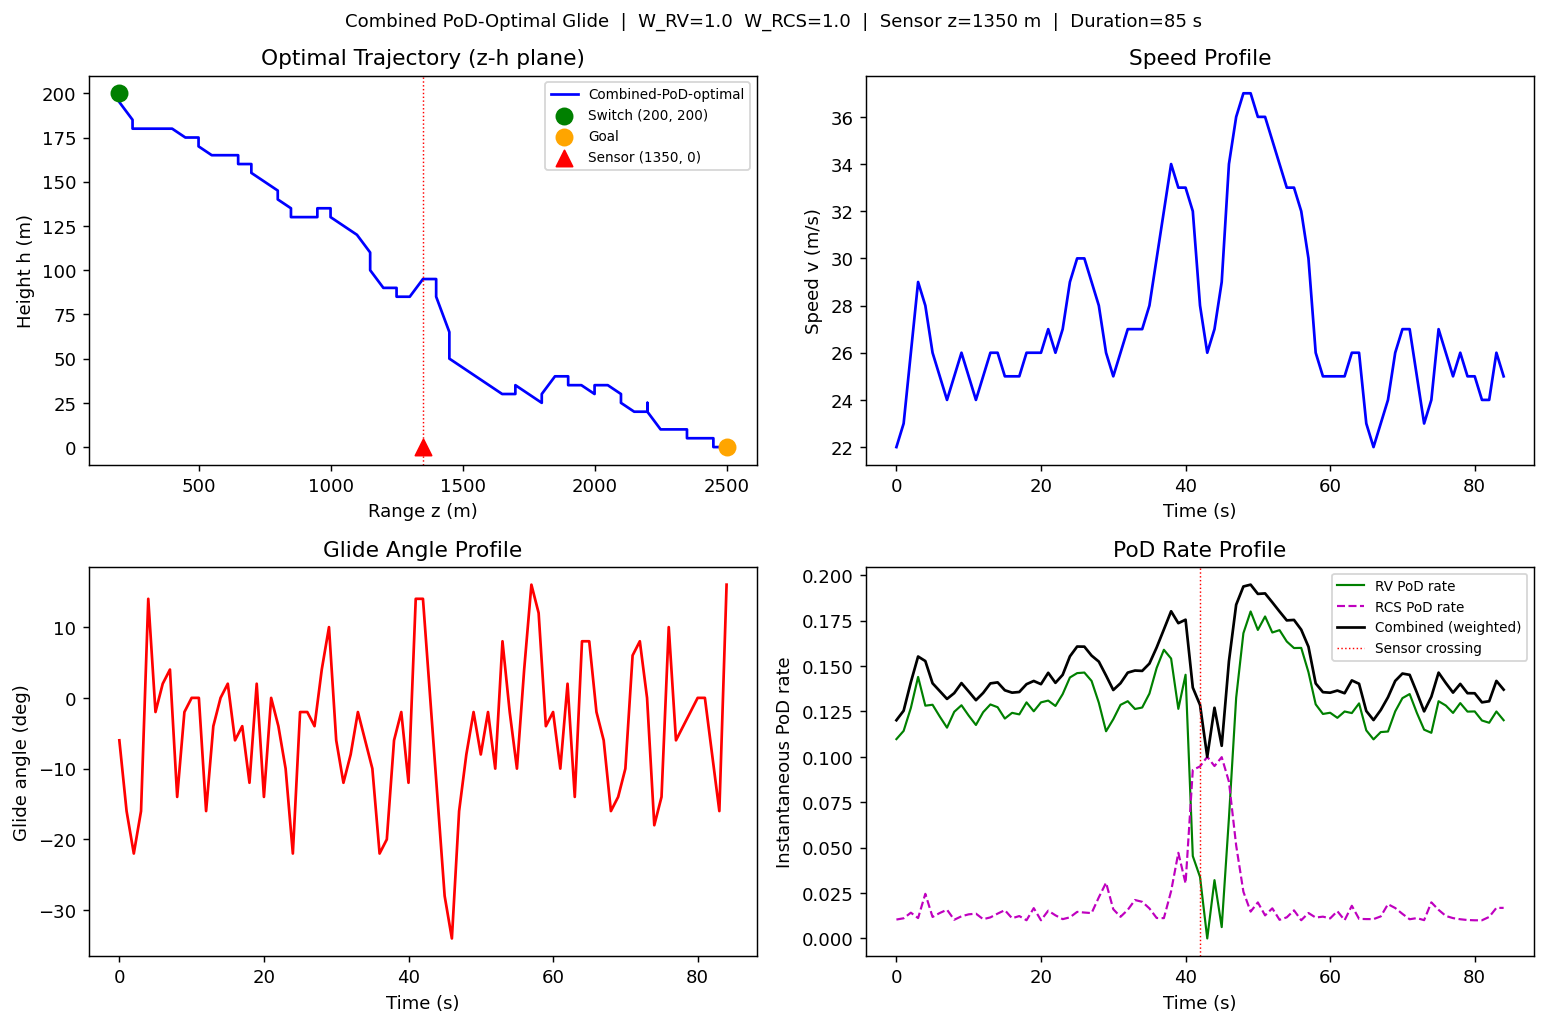

In [8]:
pod_rv_profile  = [ALPHA_SENSOR * abs(radial_velocity(z, h, v, g)) for z, h, v, g in fwd_opt]
pod_rcs_profile = [ALPHA_RCS * rcs_value(z, h, g)                   for z, h, v, g in fwd_opt]
pod_combined    = [W_RV*rv + W_RCS*rcs
                   for rv, rcs in zip(pod_rv_profile, pod_rcs_profile)]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=130)

# ── z-h plane ────────────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(opt_z, opt_h, 'b-', linewidth=1.5, label='Combined-PoD-optimal')
ax.scatter([Z_SW],     [H_SW],     c='green',  s=80, zorder=5,
           label=f'Switch ({Z_SW:.0f}, {H_SW:.0f})')
ax.scatter([Z_GOAL],   [H_GOAL],   c='orange', s=80, zorder=5, label='Goal')
ax.scatter([Z_SENSOR], [H_SENSOR], c='red',    s=80, marker='^', zorder=5,
           label=f'Sensor ({Z_SENSOR:.0f}, {H_SENSOR:.0f})')
ax.axvline(Z_SENSOR, color='r', linestyle=':', linewidth=0.8)
ax.set_xlabel('Range z (m)')
ax.set_ylabel('Height h (m)')
ax.set_title('Optimal Trajectory (z-h plane)')
ax.legend(fontsize=7.5)

# ── Speed profile ────────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(t_axis, opt_v, 'b')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Speed v (m/s)')
ax.set_title('Speed Profile')

# ── Glide angle profile ───────────────────────────────────────────────────────
ax = axes[1, 0]
ax.plot(t_axis, opt_gam, 'r')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Glide angle (deg)')
ax.set_title('Glide Angle Profile')

# ── Instantaneous PoD rate ────────────────────────────────────────────────────
ax = axes[1, 1]
ax.plot(t_axis, pod_rv_profile,  'g-',  linewidth=1.2, label='RV PoD rate')
ax.plot(t_axis, pod_rcs_profile, 'm--', linewidth=1.2, label='RCS PoD rate')
ax.plot(t_axis, pod_combined,    'k-',  linewidth=1.5, label='Combined (weighted)')
ax.axvline(t_axis[np.argmin(np.abs(np.array(opt_z) - Z_SENSOR))],
           color='r', linestyle=':', linewidth=0.8, label='Sensor crossing')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Instantaneous PoD rate')
ax.set_title('PoD Rate Profile')
ax.legend(fontsize=7.5)

plt.suptitle(
    f'Combined PoD-Optimal Glide  |  W_RV={W_RV}  W_RCS={W_RCS}  |  '
    f'Sensor z={Z_SENSOR:.0f} m  |  Duration={len(fwd_opt)*DT:.0f} s',
    fontsize=10
)
plt.tight_layout()
plt.show()


## Powered Phase

Catapult launch from $(0, 0)$ at $(v_0, \gamma_0)$. Thrust $T > 0$ (fixed schedule for now).
Reaches switching point $(Z_{sw}, H_{sw})$; the terminal $(v_{sw}, \gamma_{sw})$ from this DP
become the glide-phase initial conditions.

**Terminal constraint**: $\gamma_{sw} \leq 0$ — aircraft must be in a descending/level attitude
at the guard so the glide phase grid is valid.

**Cost**: $W_{\text{time}} \cdot dt + W_{\text{fuel}} \cdot T \cdot dt$

In [9]:
# ── Catapult launch conditions ───────────────────────────────────────────────
Z_LAUNCH   = 0.0
H_LAUNCH   = 0.0
V_LAUNCH   = V_STALL           # 14 m/s  — minimum airspeed at launch
GAM_LAUNCH = np.radians(45.0)  # 45 deg nose-up catapult launch

# ── Powered phase grid ────────────────────────────────────────────────────────
# Finer z/h resolution than glide (shorter domain: 0->200 m in each axis).
# Gamma range extended to +90 deg to capture the climbing phase.
# V_GRID reused from glide phase (same airspeed range).
DZ_POW = 20.0
DH_POW = 10.0
DT_POW = 0.25   # smaller time step for powered phase — avoids pitch-up instability at high thrust

Z_GRID_POW   = np.arange(Z_LAUNCH, Z_SW + DZ_POW, DZ_POW)
H_GRID_POW   = np.arange(H_LAUNCH, H_SW + DH_POW, DH_POW)
GAM_GRID_POW = np.arange(np.radians(-90.0), np.radians(90.0) + DGAM, DGAM)

NZ_POW = len(Z_GRID_POW)
NH_POW = len(H_GRID_POW)
NV_POW = NV                    # reuse V_GRID and NV from glide phase
NG_POW = len(GAM_GRID_POW)

print(f'Launch      : z={Z_LAUNCH:.0f} h={H_LAUNCH:.0f} '
      f'v={V_LAUNCH:.1f} m/s gamma={np.degrees(GAM_LAUNCH):.0f} deg')
print(f'Switch      : z={Z_SW:.0f} h={H_SW:.0f}')
print(f'DT_POW      : {DT_POW} s  (glide DT={DT} s)')
print(f'Powered grid: NZ={NZ_POW} NH={NH_POW} NV={NV_POW} NG={NG_POW} '
      f'total={NZ_POW*NH_POW*NV_POW*NG_POW:,}')


Launch      : z=0 h=0 v=14.0 m/s gamma=45 deg
Switch      : z=200 h=200
DT_POW      : 0.25 s  (glide DT=1.0 s)
Powered grid: NZ=11 NH=21 NV=87 NG=91 total=1,828,827


In [10]:
def thrust_profile(z, h, v, gamma):
    # Fixed at T_MAX for now. Extend to state/time-dependent schedule later.
    return T_MAX

W_TIME_POW = 1.0   # weight on flight time
W_FUEL_POW = 0.1   # weight on fuel (T*dt); separates when T becomes variable

def cost_powered(z, h, v, gamma, CL, dt):
    T = thrust_profile(z, h, v, gamma)
    return W_TIME_POW * dt + W_FUEL_POW * T * dt

print(f'T_MAX        : {T_MAX} N   (T/W = {T_MAX/(M*G):.2f})')
print(f'W_TIME_POW   : {W_TIME_POW}')
print(f'W_FUEL_POW   : {W_FUEL_POW}')
print(f'Cost/step    : {W_TIME_POW*DT + W_FUEL_POW*T_MAX*DT:.3f}  (at T=T_MAX)')


T_MAX        : 25.0 N   (T/W = 1.70)
W_TIME_POW   : 1.0
W_FUEL_POW   : 0.1
Cost/step    : 3.500  (at T=T_MAX)


In [11]:
def snap_powered(z, h, v, gamma):
    iz   = int(round((z     - Z_GRID_POW[0]) / DZ_POW))
    ih   = int(round((h     - H_GRID_POW[0]) / DH_POW))
    iv   = int(round((v     - V_GRID[0])      / DV))
    igam = int(round((gamma  - GAM_GRID_POW[0]) / DGAM))
    if 0 <= iz < NZ_POW and 0 <= ih < NH_POW and 0 <= iv < NV_POW and 0 <= igam < NG_POW:
        return iz, ih, iv, igam
    return None


def bellman_powered(cost_fn, label=''):
    s_start = snap_powered(Z_LAUNCH, H_LAUNCH, V_LAUNCH, GAM_LAUNCH)
    if s_start is None:
        raise RuntimeError('Launch state out of powered grid bounds.')

    V          = {s_start: 0.0}
    prev_state = {}
    cont       = {s_start: (Z_LAUNCH, H_LAUNCH, V_LAUNCH, GAM_LAUNCH)}
    heap       = [(0.0, 0, s_start)]
    counter    = 1

    while heap:
        cost, _, s = heapq.heappop(heap)
        if cost > V.get(s, float('inf')) + 1e-9:
            continue

        z, h, v, gamma = cont[s]
        T = thrust_profile(z, h, v, gamma)

        for CL in CL_DISCRETE:
            zn, hn, vn, gn = rk4_step(z, h, v, gamma, CL, DT_POW, T=T)

            if hn < H_LAUNCH: continue
            if zn < Z_LAUNCH: continue
            if vn < V_STALL:  continue

            s_next = snap_powered(zn, hn, vn, gn)
            if s_next is None: continue

            new_cost = cost + cost_fn(z, h, v, gamma, CL, DT_POW)
            if new_cost < V.get(s_next, float('inf')):
                V[s_next]          = new_cost
                prev_state[s_next] = s
                cont[s_next]       = (zn, hn, vn, gn)
                heapq.heappush(heap, (new_cost, counter, s_next))
                counter += 1

    iz_sw_p = round((Z_SW - Z_GRID_POW[0]) / DZ_POW)
    ih_sw_p = round((H_SW - H_GRID_POW[0]) / DH_POW)
    tag     = f'[{label}] ' if label else ''

    sw_states = [(iv, ig, V[s]) for iv in range(NV_POW) for ig in range(NG_POW)
                 if GAM_GRID_POW[ig] <= GAM_GRID[-1] and (s := (iz_sw_p, ih_sw_p, iv, ig)) in V]
    if sw_states:
        best_iv, best_ig, best_cost = min(sw_states, key=lambda x: x[2])
        print(f'{tag}Optimal cost : {best_cost:.4f}')
        print(f'{tag}v_sw={V_GRID[best_iv]:.2f} m/s  '
              f'gamma_sw={np.degrees(GAM_GRID_POW[best_ig]):.2f} deg')
    else:
        print(f'{tag}WARNING: no terminal state found at switch point.')
    print(f'{tag}States covered : {len(V)}')
    return V, prev_state


def extract_powered(V, prev_state):
    iz_sw_p = round((Z_SW - Z_GRID_POW[0]) / DZ_POW)
    ih_sw_p = round((H_SW - H_GRID_POW[0]) / DH_POW)
    s_start = snap_powered(Z_LAUNCH, H_LAUNCH, V_LAUNCH, GAM_LAUNCH)

    # Primary: prefer gamma <= 0 (descending/level → clean glide start, no zoom climb)
    best_s, best_val = None, float('inf')
    for iv in range(NV_POW):
        for ig in range(NG_POW):
            if GAM_GRID_POW[ig] > 0.0: continue              # must be descending/level
            if GAM_GRID_POW[ig] > GAM_GRID[-1]: continue     # must fit in glide grid
            s = (iz_sw_p, ih_sw_p, iv, ig)
            if s in V and V[s] < best_val:
                best_val, best_s = V[s], s

    if best_s is None:
        # Fallback: accept any gamma that fits in glide grid (zoom climb will happen;
        # H_HEADROOM=300m provides enough clearance for worst-case zoom)
        print('WARNING: no γ≤0 state at switch. Falling back — zoom climb expected.')
        best_val = float('inf')
        for iv in range(NV_POW):
            for ig in range(NG_POW):
                if GAM_GRID_POW[ig] > GAM_GRID[-1]: continue
                s = (iz_sw_p, ih_sw_p, iv, ig)
                if s in V and V[s] < best_val:
                    best_val, best_s = V[s], s

    if best_s is None:
        raise RuntimeError('Switch point (Z_SW, H_SW) not reachable.')

    iz_t, ih_t, iv_t, ig_t = best_s
    v_sw_new   = V_GRID[iv_t]
    gam_sw_new = GAM_GRID_POW[ig_t]

    traj_idx = []
    s = best_s
    while True:
        traj_idx.append(s)
        if s == s_start or s not in prev_state:
            break
        s = prev_state[s]

    traj_cont = [(Z_GRID_POW[iz], H_GRID_POW[ih], V_GRID[iv], GAM_GRID_POW[ig])
                 for iz, ih, iv, ig in traj_idx]

    status = 'reached launch' if traj_idx[-1] == s_start else \
             f'stopped at z={Z_GRID_POW[traj_idx[-1][0]]:.0f} h={H_GRID_POW[traj_idx[-1][1]]:.0f}'
    print(f'Extraction : {len(traj_cont)} steps, {status}.')
    print(f'v_sw={v_sw_new:.2f} m/s  gamma_sw={np.degrees(gam_sw_new):.2f} deg  cost={best_val:.4f}')
    return traj_cont, v_sw_new, gam_sw_new


Optimal switch point search  (T_MAX=25 N, T/W=1.70)
Building transition tables ... done (0.05 s)  pow: 44×46=2024 entries  glide: 44×35=1540 entries
Step 1  forward BFS (powered) ... done (0.0 s)  1,105 states
Step 2  backward BFS (glide)  ... done (3.9 s)  6,058,342 states
Step 3  sweeping (z,h) candidates ... done (0.001 s)

── Optimal switch point ──
  (Z_SW, H_SW) = (100, 40) m
  Overlap      = 7 (v,γ) cells  |  feasible positions: 8
  Aligned z candidates: ['z=0(n=1)', 'z=100(n=6)', 'z=200(n=1)']


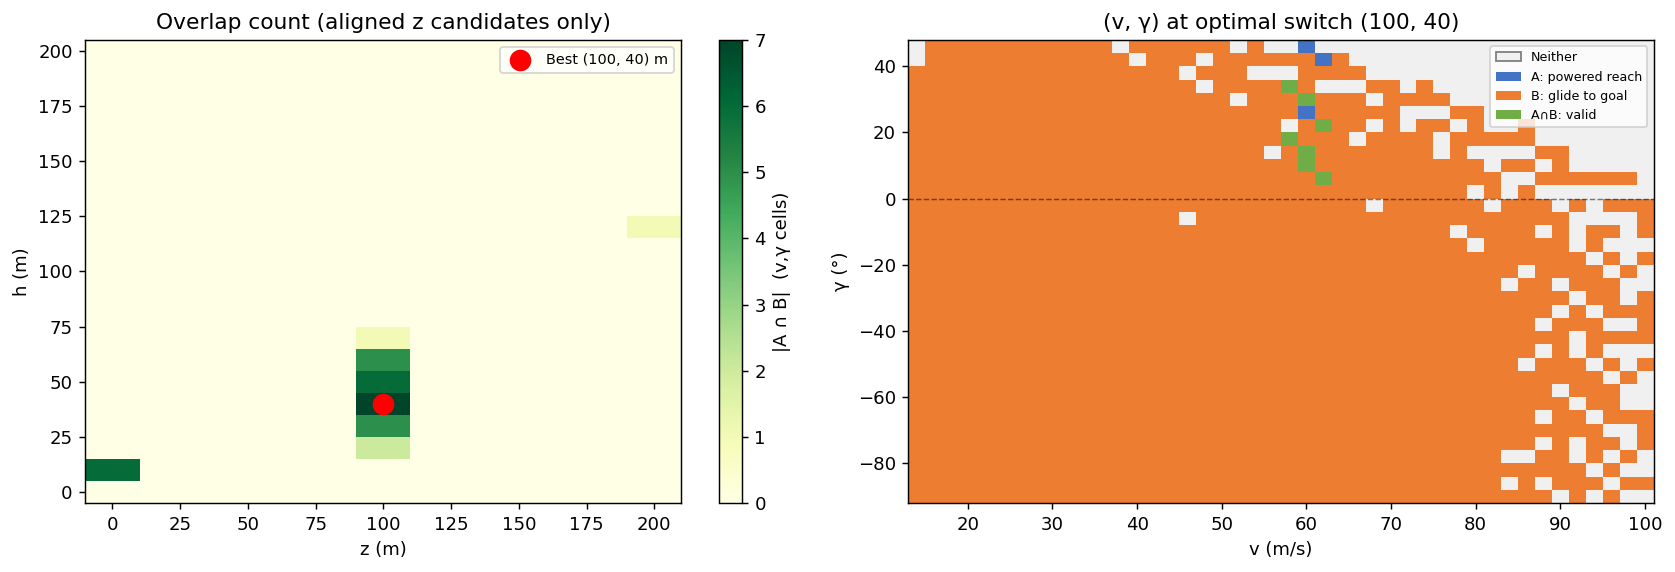

Total: 4.1 s


In [12]:
from collections import deque

def find_switch_point():
    """
    Finds optimal (Z_SW, H_SW) by sweeping the powered grid.

    Speed-up tricks vs naive BFS:
      1. Coarse (v,γ) grid  (DV_R=2 m/s, DGAM_R=4°)  — ~30x fewer states.
      2. Precomputed transition table — zero function calls inside BFS loops.
      3. CL vectorisation — dz/dh/dv are CL-independent; only dγ varies.
         All 10 CL gamma outcomes computed at once and deduplicated.

    Grid alignment constraint: only Z positions where (Z_GOAL - z) % DZ == 0 are
    considered as switch candidates, ensuring Z_GOAL always falls exactly on Z_GRID.

    NOTE: BFS uses DT=1s (coarse, grid-compatible).  Only the Dijkstra (bellman_powered)
    uses the finer DT_POW.  With DT_POW=0.25 the BFS diz is 0 for ~10 steps and the
    reachability map becomes wrong.
    """

    # ── Coarse grids (BFS only, not used for DP) ──────────────────────────────
    DV_R   = 2.0
    DGAM_R = np.radians(4.0)
    V_R    = np.arange(V_STALL, V_MAX   + DV_R,   DV_R)
    GAMP_R = np.arange(np.radians(-90.), np.radians( 90.) + DGAM_R, DGAM_R)
    GAMG_R = np.arange(np.radians(-90.), np.radians( 46.) + DGAM_R, DGAM_R)
    NVR = len(V_R);  NGPR = len(GAMP_R);  NGGR = len(GAMG_R)

    Z_WIDE = np.arange(Z_LAUNCH, Z_GOAL + DZ, DZ)
    H_WIDE = np.arange(H_GOAL,   H_GRID_POW[-1] + H_HEADROOM + DH, DH)
    NZ_W, NH_W = len(Z_WIDE), len(H_WIDE)

    # ── Precompute transition table ───────────────────────────────────────────
    def build_transitions(GAM_R_in, NGR_in, dt, dz_grid, dh_grid, T=0.0):
        diz  = np.zeros((NVR, NGR_in), dtype=np.int16)
        dih  = np.zeros((NVR, NGR_in), dtype=np.int16)
        iv_n = np.full ((NVR, NGR_in), -1, dtype=np.int16)
        uig  = [[[] for _ in range(NGR_in)] for _ in range(NVR)]
        for iv in range(NVR):
            v = float(V_R[iv])
            D = 0.5*RHO*v*v*S*CD
            for ig in range(NGR_in):
                gamma  = float(GAM_R_in[ig])
                cg, sg = np.cos(gamma), np.sin(gamma)
                diz[iv, ig] = int(round(v*cg*dt / dz_grid))
                dih[iv, ig] = int(round(v*sg*dt / dh_grid))
                vn = v + (-G*sg - D/M + T/M)*dt
                ivn = int(round((vn - V_R[0]) / DV_R))
                if 0 <= ivn < NVR:
                    iv_n[iv, ig] = ivn
                L_arr  = 0.5*RHO*v*v*S*CL_DISCRETE
                gn_arr = gamma + (L_arr/(M*v) - G*cg/v)*dt
                seen = set()
                for gn in gn_arr:
                    ig_n = int(round((gn - GAM_R_in[0]) / DGAM_R))
                    if 0 <= ig_n < NGR_in and ig_n not in seen:
                        seen.add(ig_n)
                        uig[iv][ig].append(ig_n)
        return diz.tolist(), dih.tolist(), iv_n.tolist(), uig

    print('Building transition tables ...', end=' ', flush=True)
    t0 = time.time()
    # BFS uses DT=1s (not DT_POW) — DT_POW is too small relative to DZ_POW/DH_POW
    # so transitions give diz=0 for 10+ steps, breaking the reachability map.
    diz_p, dih_p, ivn_p, uig_p = build_transitions(GAMP_R, NGPR,  DT, DZ_POW, DH_POW, T=T_MAX)
    diz_g, dih_g, ivn_g, uig_g = build_transitions(GAMG_R, NGGR, -DT, DZ,     DH,     T=0.0)
    print(f'done ({time.time()-t0:.2f} s)  '
          f'pow: {NVR}×{NGPR}={NVR*NGPR} entries  '
          f'glide: {NVR}×{NGGR}={NVR*NGGR} entries')

    # ── Step 1: Forward BFS (powered grid) ───────────────────────────────────
    print('Step 1  forward BFS (powered) ...', end=' ', flush=True)
    t0 = time.time()

    vis_p = np.zeros((NZ_POW, NH_POW, NVR, NGPR), dtype=bool)
    iv0 = int(round((V_LAUNCH   - V_R[0])    / DV_R))
    ig0 = int(round((GAM_LAUNCH - GAMP_R[0]) / DGAM_R))
    iz0 = int(round((Z_LAUNCH   - Z_GRID_POW[0]) / DZ_POW))
    ih0 = int(round((H_LAUNCH   - H_GRID_POW[0]) / DH_POW))
    if not (0<=iv0<NVR and 0<=ig0<NGPR and 0<=iz0<NZ_POW and 0<=ih0<NH_POW):
        print('\nERROR: launch state out of powered grid.'); return None, None
    s0 = (iz0, ih0, iv0, ig0)
    vis_p[s0] = True
    queue = deque([s0])
    while queue:
        iz, ih, iv, ig = queue.popleft()
        iv_n = ivn_p[iv][ig]
        if iv_n < 0: continue
        iz_n = iz + diz_p[iv][ig]
        ih_n = ih + dih_p[iv][ig]
        if not (0 <= iz_n < NZ_POW and 0 <= ih_n < NH_POW): continue
        for ig_n in uig_p[iv][ig]:
            sn = (iz_n, ih_n, iv_n, ig_n)
            if vis_p[sn]: continue
            vis_p[sn] = True
            queue.append(sn)
    print(f'done ({time.time()-t0:.1f} s)  {vis_p.sum():,} states')

    # ── Step 2: Backward BFS (wide glide grid, goal → switch) ────────────────
    print('Step 2  backward BFS (glide)  ...', end=' ', flush=True)
    t0 = time.time()

    vis_w = np.zeros((NZ_W, NH_W, NVR, NGGR), dtype=bool)
    iz_gl = int(round((Z_GOAL - Z_WIDE[0]) / DZ))
    ih_gl = int(round((H_GOAL - H_WIDE[0]) / DH))
    vis_w[iz_gl, ih_gl, :, :] = True
    queue = deque((iz_gl, ih_gl, iv, ig)
                  for iv in range(NVR) for ig in range(NGGR))
    while queue:
        iz, ih, iv, ig = queue.popleft()
        iv_n = ivn_g[iv][ig]
        if iv_n < 0: continue
        iz_n = iz + diz_g[iv][ig]
        ih_n = ih + dih_g[iv][ig]
        if not (0 <= iz_n < NZ_W and 0 <= ih_n < NH_W): continue
        for ig_n in uig_g[iv][ig]:
            sn = (iz_n, ih_n, iv_n, ig_n)
            if vis_w[sn]: continue
            vis_w[sn] = True
            queue.append(sn)
    print(f'done ({time.time()-t0:.1f} s)  {vis_w.sum():,} states')

    # ── Step 3: Sweep all (z,h) candidates in powered grid ───────────────────
    print('Step 3  sweeping (z,h) candidates ...', end=' ', flush=True)
    t0 = time.time()

    p2g = np.full(NGPR, -1, dtype=int)
    for ig_p in range(NGPR):
        ig_g = int(round((GAMP_R[ig_p] - GAMG_R[0]) / DGAM_R))
        if 0 <= ig_g < NGGR:
            p2g[ig_p] = ig_g

    ov_map = np.zeros((NZ_POW, NH_POW), dtype=int)
    for iz_p in range(NZ_POW):
        z_cand = float(Z_GRID_POW[iz_p])
        rem = (Z_GOAL - z_cand) % DZ
        if rem > 1e-6 and (DZ - rem) > 1e-6:
            continue
        for ih_p in range(NH_POW):
            if not vis_p[iz_p, ih_p].any(): continue
            iz_w = int(round((Z_GRID_POW[iz_p] - Z_WIDE[0]) / DZ))
            ih_w = int(round((H_GRID_POW[ih_p] - H_WIDE[0]) / DH))
            if not (0 <= iz_w < NZ_W and 0 <= ih_w < NH_W): continue
            A = np.zeros((NVR, NGGR), dtype=bool)
            for ig_p2 in range(NGPR):
                ig_g = p2g[ig_p2]
                if ig_g >= 0:
                    A[:, ig_g] |= vis_p[iz_p, ih_p, :, ig_p2]
            ov_map[iz_p, ih_p] = int((A & vis_w[iz_w, ih_w]).sum())
    print(f'done ({time.time()-t0:.3f} s)')

    # ── Pick best ─────────────────────────────────────────────────────────────
    iz_b, ih_b = np.unravel_index(ov_map.argmax(), ov_map.shape)
    Z_SW_opt = float(Z_GRID_POW[iz_b])
    H_SW_opt = float(H_GRID_POW[ih_b])
    n_ov   = int(ov_map[iz_b, ih_b])
    n_feas = int((ov_map > 0).sum())
    aligned = [(float(Z_GRID_POW[i]), int((ov_map[i]>0).sum()))
               for i in range(NZ_POW)
               if abs((Z_GOAL-Z_GRID_POW[i])%DZ)<1e-6 or abs((Z_GOAL-Z_GRID_POW[i])%DZ-DZ)<1e-6]
    print(f'\n── Optimal switch point ──')
    print(f'  (Z_SW, H_SW) = ({Z_SW_opt:.0f}, {H_SW_opt:.0f}) m')
    print(f'  Overlap      = {n_ov} (v,γ) cells  |  feasible positions: {n_feas}')
    print(f'  Aligned z candidates: {[f"z={z:.0f}(n={n})" for z,n in aligned]}')

    # ── Plots ─────────────────────────────────────────────────────────────────
    from matplotlib.colors import ListedColormap
    from matplotlib.patches import Patch

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), dpi=130)

    ax = axes[0]
    im = ax.pcolormesh(Z_GRID_POW, H_GRID_POW, ov_map.T, cmap='YlGn', shading='nearest')
    plt.colorbar(im, ax=ax, label='|A ∩ B|  (v,γ cells)')
    ax.scatter([Z_SW_opt], [H_SW_opt], c='red', s=120, zorder=5,
               label=f'Best ({Z_SW_opt:.0f}, {H_SW_opt:.0f}) m')
    ax.set_xlabel('z (m)'); ax.set_ylabel('h (m)')
    ax.set_title('Overlap count (aligned z candidates only)')
    ax.legend(fontsize=8)

    ax = axes[1]
    A_best = np.zeros((NVR, NGGR), dtype=bool)
    for ig_p2 in range(NGPR):
        ig_g = p2g[ig_p2]
        if ig_g >= 0:
            A_best[:, ig_g] |= vis_p[iz_b, ih_b, :, ig_p2]
    iz_w_b = int(round((Z_SW_opt - Z_WIDE[0]) / DZ))
    ih_w_b = int(round((H_SW_opt - H_WIDE[0]) / DH))
    B_best = vis_w[iz_w_b, ih_w_b]
    img   = A_best.T.astype(float) + 2.0 * B_best.T.astype(float)
    cmap2 = ListedColormap(['#f0f0f0', '#4472C4', '#ED7D31', '#70AD47'])
    ax.pcolormesh(V_R, np.degrees(GAMG_R), img, cmap=cmap2, vmin=-0.5, vmax=3.5, shading='nearest')
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.legend(handles=[
        Patch(facecolor='#f0f0f0', edgecolor='gray', label='Neither'),
        Patch(facecolor='#4472C4', label='A: powered reach'),
        Patch(facecolor='#ED7D31', label='B: glide to goal'),
        Patch(facecolor='#70AD47', label='A∩B: valid'),
    ], fontsize=7, loc='upper right')
    ax.set_xlabel('v (m/s)'); ax.set_ylabel('γ (°)')
    ax.set_title(f'(v, γ) at optimal switch ({Z_SW_opt:.0f}, {H_SW_opt:.0f})')
    plt.tight_layout(); plt.show()

    return Z_SW_opt, H_SW_opt


print(f'Optimal switch point search  (T_MAX={T_MAX:.0f} N, T/W={T_MAX/(M*G):.2f})')
_t = time.time()
Z_SW_opt, H_SW_opt = find_switch_point()
print(f'Total: {time.time()-_t:.1f} s')


In [13]:
# ── Apply optimal switch point and rebuild all dependent grids ────────────────
Z_SW    = Z_SW_opt
H_SW    = H_SW_opt
Z_SENSOR = (Z_SW + Z_GOAL) / 2.0

# Do NOT rebuild Z_GRID_POW / H_GRID_POW here.
# The powered DP needs the full original grid (NZ_POW=11, NH_POW=21) so the
# catapult arc — which temporarily exceeds H_SW before arriving at the switch —
# can be explored. Shrinking to [0,Z_SW]×[0,H_SW] cuts off those intermediate
# states and makes the switch point unreachable.

# Glide grid: starts at new Z_SW (Z_SW_opt is guaranteed DZ-aligned so Z_GOAL
# falls exactly on Z_GRID — checked by find_switch_point's alignment filter)
Z_GRID = np.arange(Z_SW,   Z_GOAL + DZ, DZ)
H_GRID = np.arange(H_GOAL, H_SW + H_HEADROOM + DH, DH)
NZ, NH = len(Z_GRID), len(H_GRID)

# Sanity check
iz_goal_check = round((Z_GOAL - Z_GRID[0]) / DZ)
assert abs(Z_GRID[iz_goal_check] - Z_GOAL) < 1e-6, \
    f'Z_GOAL not on Z_GRID: Z_GRID[{iz_goal_check}]={Z_GRID[iz_goal_check]:.1f}'

print(f'Switch point : Z_SW={Z_SW:.0f} m   H_SW={H_SW:.0f} m')
print(f'Sensor       : Z_SENSOR={Z_SENSOR:.1f} m')
print(f'Powered grid : NZ={NZ_POW}  NH={NH_POW}  (unchanged)  total={(NZ_POW*NH_POW*NV_POW*NG_POW):,}')
print(f'Glide  grid  : NZ={NZ}  NH={NH}   total={(NZ*NH*NV*NG):,}')
print(f'Z_GOAL alignment: Z_GRID[{iz_goal_check}] = {Z_GRID[iz_goal_check]:.0f} ✓')


Switch point : Z_SW=100 m   H_SW=40 m
Sensor       : Z_SENSOR=1300.0 m
Powered grid : NZ=11  NH=21  (unchanged)  total=1,828,827
Glide  grid  : NZ=49  NH=69   total=20,296,143
Z_GOAL alignment: Z_GRID[48] = 2500 ✓


In [14]:
print('Running powered phase Dijkstra...')
print(f'  Launch : z={Z_LAUNCH:.0f} h={H_LAUNCH:.0f} v={V_LAUNCH:.1f} m/s '
      f'gamma={np.degrees(GAM_LAUNCH):.0f} deg')
print(f'  Switch : z={Z_SW:.0f} h={H_SW:.0f}')
print(f'  Thrust : T={T_MAX:.1f} N  (T/W={T_MAX/(M*G):.2f})')
print()

t0 = time.time()
V_pow, prev_pow = bellman_powered(cost_powered, label='powered')
print(f'Elapsed: {time.time()-t0:.1f} s')

traj_pow_cont, V_SW, GAM_SW = extract_powered(V_pow, prev_pow)
fwd_pow = list(reversed(traj_pow_cont))

pow_z   = [s[0] for s in fwd_pow]
pow_h   = [s[1] for s in fwd_pow]
pow_v   = [s[2] for s in fwd_pow]
pow_gam = [np.degrees(s[3]) for s in fwd_pow]
t_pow   = np.arange(len(fwd_pow)) * DT

print(f'\nPowered phase  : {len(fwd_pow)*DT:.1f} s  ({len(fwd_pow)} steps)')
print(f'V_SW updated   : {V_SW:.2f} m/s  (was {V_STALL:.1f} m/s)')
print(f'GAM_SW updated : {np.degrees(GAM_SW):.2f} deg  (was -5.0 deg)')


Running powered phase Dijkstra...
  Launch : z=0 h=0 v=14.0 m/s gamma=45 deg
  Switch : z=100 h=40
  Thrust : T=25.0 N  (T/W=1.70)

[powered] Optimal cost : 11.3750
[powered] v_sw=50.00 m/s  gamma_sw=20.00 deg
[powered] States covered : 8664
Elapsed: 1.2 s
Extraction : 14 steps, reached launch.
v_sw=50.00 m/s  gamma_sw=20.00 deg  cost=11.3750

Powered phase  : 14.0 s  (14 steps)
V_SW updated   : 50.00 m/s  (was 14.0 m/s)
GAM_SW updated : 20.00 deg  (was -5.0 deg)


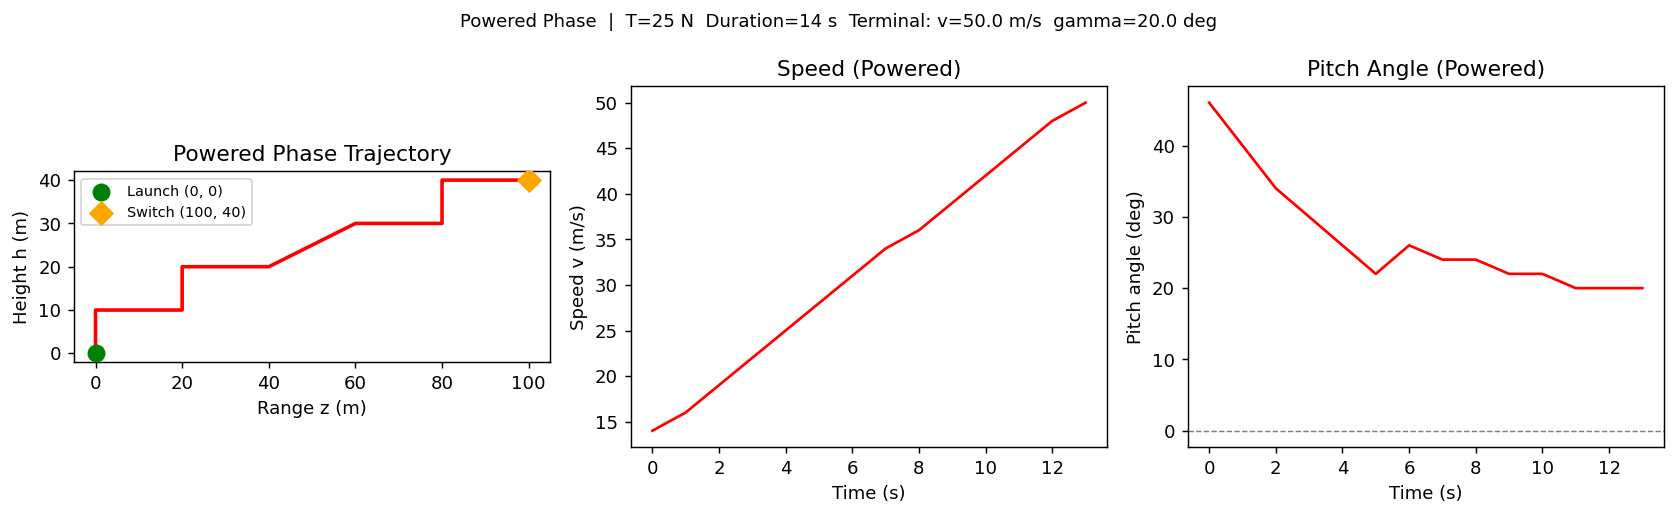

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), dpi=130)

ax = axes[0]
ax.plot(pow_z, pow_h, 'r-', linewidth=2)
ax.scatter([Z_LAUNCH], [H_LAUNCH], c='green',  s=80, zorder=5,
           label=f'Launch ({Z_LAUNCH:.0f}, {H_LAUNCH:.0f})')
ax.scatter([Z_SW],     [H_SW],     c='orange', s=80, marker='D', zorder=5,
           label=f'Switch ({Z_SW:.0f}, {H_SW:.0f})')
ax.set_xlabel('Range z (m)')
ax.set_ylabel('Height h (m)')
ax.set_title('Powered Phase Trajectory')
ax.legend(fontsize=8)
ax.set_aspect('equal')

axes[1].plot(t_pow, pow_v, 'r')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Speed v (m/s)')
axes[1].set_title('Speed (Powered)')

axes[2].plot(t_pow, pow_gam, 'r')
axes[2].axhline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Pitch angle (deg)')
axes[2].set_title('Pitch Angle (Powered)')

plt.suptitle(
    f'Powered Phase  |  T={T_MAX:.0f} N  Duration={len(fwd_pow)*DT:.0f} s  '
    f'Terminal: v={V_SW:.1f} m/s  gamma={np.degrees(GAM_SW):.1f} deg',
    fontsize=10
)
plt.tight_layout()
plt.show()


Glide phase initial conditions (from powered phase):
  V_SW=50.00 m/s   GAM_SW=20.00 deg

[combined-PoD] Optimal cost   : 13.4433
[combined-PoD] States covered : 560280
Elapsed: 85.1 s
Extraction: 110 steps, reached start. Terminal z=2500 h=0. Total cost: 13.4433


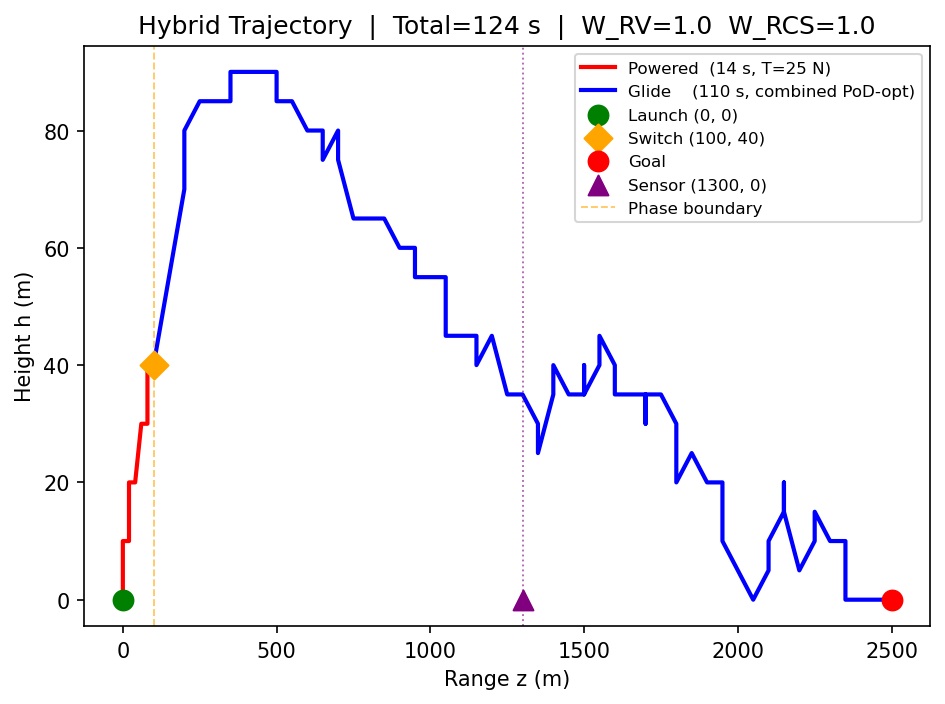

In [16]:
# Re-run glide phase with V_SW, GAM_SW now determined by the powered phase DP
print(f'Glide phase initial conditions (from powered phase):')
print(f'  V_SW={V_SW:.2f} m/s   GAM_SW={np.degrees(GAM_SW):.2f} deg')
print()

t0 = time.time()
V_opt, prev_opt = bellman_general(cost_combined_pod, label='combined-PoD')
print(f'Elapsed: {time.time()-t0:.1f} s')

_, traj_cont_opt = extract_trajectory(V_opt, prev_opt)
fwd_opt = list(reversed(traj_cont_opt))
opt_z   = [s[0] for s in fwd_opt]
opt_h   = [s[1] for s in fwd_opt]

# ── Combined trajectory plot ──────────────────────────────────────────────────
fig, ax = plt.subplots(dpi=150)

ax.plot(pow_z, pow_h, 'r-',  linewidth=2.0,
        label=f'Powered  ({len(fwd_pow)*DT:.0f} s, T={T_MAX:.0f} N)')
ax.plot(opt_z, opt_h, 'b-',  linewidth=2.0,
        label=f'Glide    ({len(fwd_opt)*DT:.0f} s, combined PoD-opt)')

ax.scatter([Z_LAUNCH], [H_LAUNCH], c='green',  s=90, zorder=5, label='Launch (0, 0)')
ax.scatter([Z_SW],     [H_SW],     c='orange', s=90, marker='D', zorder=5,
           label=f'Switch ({Z_SW:.0f}, {H_SW:.0f})')
ax.scatter([Z_GOAL],   [H_GOAL],   c='red',    s=90, zorder=5, label='Goal')
ax.scatter([Z_SENSOR], [H_SENSOR], c='purple', s=90, marker='^', zorder=5,
           label=f'Sensor ({Z_SENSOR:.0f}, 0)')

ax.axvline(Z_SW,     color='orange', linestyle='--', linewidth=0.9, alpha=0.6,
           label='Phase boundary')
ax.axvline(Z_SENSOR, color='purple', linestyle=':',  linewidth=0.9, alpha=0.6)

ax.set_xlabel('Range z (m)')
ax.set_ylabel('Height h (m)')
ax.set_title(
    f'Hybrid Trajectory  |  '
    f'Total={len(fwd_pow)*DT + len(fwd_opt)*DT:.0f} s  |  '
    f'W_RV={W_RV}  W_RCS={W_RCS}'
)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
